<a href="https://colab.research.google.com/github/KaterinaSor2005/homework_Sorokina332/blob/main/hw3(random).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
#задача 1
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare

np.random.seed(42)

def generate_random_uniform_sequence(length=1000, low=0, high=10):
    return np.random.randint(low, high + 1, size=length)

def generate_random_normal_sequence(length=1000, mean=5, std_dev=2, bins=10):
    raw_normal = np.random.normal(mean, std_dev, size=length)
    min_val = np.min(raw_normal)
    max_val = np.max(raw_normal)
    if max_val == min_val:
        return np.zeros(length, dtype=int)
    normalized_data = (raw_normal - min_val) / (max_val - min_val)
    discretized_data = np.floor(normalized_data * bins).astype(int)
    discretized_data = np.clip(discretized_data, 0, bins - 1)
    return discretized_data

def generate_repeating_sequence(length=1000, pattern_values=[0, 1, 2]):
    pattern_length = len(pattern_values)
    sequence = np.array([pattern_values[i % pattern_length] for i in range(length)])
    return sequence

def generate_autocorrelated_sequence(length=1000, start_value=5, factor=0.5, noise_scale=1, low=0, high=9):
    sequence = np.zeros(length, dtype=int)
    sequence[0] = start_value
    for i in range(1, length):
        next_val = round(sequence[i-1] * factor + np.random.normal(0, noise_scale))
        sequence[i] = np.clip(int(next_val), low, high)
    return sequence


random_uniform_sequence = generate_random_uniform_sequence()
random_normal_sequence = generate_random_normal_sequence()
repeating_sequence = generate_repeating_sequence()
autocorrelated_sequence = generate_autocorrelated_sequence(low=0, high=9)

samples = {
    'random_uniform': (random_uniform_sequence, 11),
    'random_normal': (random_normal_sequence, 10),
    'repeating_pattern': (repeating_sequence, 3),
    'autocorrelated': (autocorrelated_sequence, 10)
}

def serial_test(sequence, M, block_len=2):

    N = len(sequence)
    n_blocks = N // block_len
    blocks = sequence[:n_blocks * block_len].reshape(-1, block_len)


    if np.any(blocks < 0) or np.any(blocks >= M):
        raise ValueError(f"Значения должны быть в [0, {M-1}]")


    powers = M ** np.arange(block_len - 1, -1, -1)
    indices = np.dot(blocks, powers)

    observed = np.bincount(indices, minlength=M**block_len)
    expected = n_blocks / (M ** block_len)

    chi2, p_value = chisquare(observed, f_exp=expected)
    return chi2, p_value, n_blocks


print("Результаты serial test (длина блока = 2):\n")
for name, (seq, M) in samples.items():
    chi2, p, n_blocks = serial_test(seq, M, block_len=2)
    print(f"{name}:")
    print(f"  число блоков = {n_blocks}")
    print(f"  статистика χ² = {chi2:.4f}")
    print(f"  p-value = {p:.6f}\n")


Результаты serial test (длина блока = 2):

random_uniform:
  число блоков = 500
  статистика χ² = 116.1320
  p-value = 0.582872

random_normal:
  число блоков = 500
  статистика χ² = 774.8000
  p-value = 0.000000

repeating_pattern:
  число блоков = 500
  статистика χ² = 1000.0120
  p-value = 0.000000

autocorrelated:
  число блоков = 500
  статистика χ² = 10294.4000
  p-value = 0.000000



Тест хи-квадрат на равномерность
------------------------------------------------------------
Плохой ГСЧ: chi2 = 120.00, p-value = 1.109e-16
  → p-value очень мал, распределение значимо отличается от равномерного (проблемы!)

Хороший ГСЧ: chi2 = 11.90, p-value = 0.890
  → p-value > 0.01, распределение равномерное (OK)


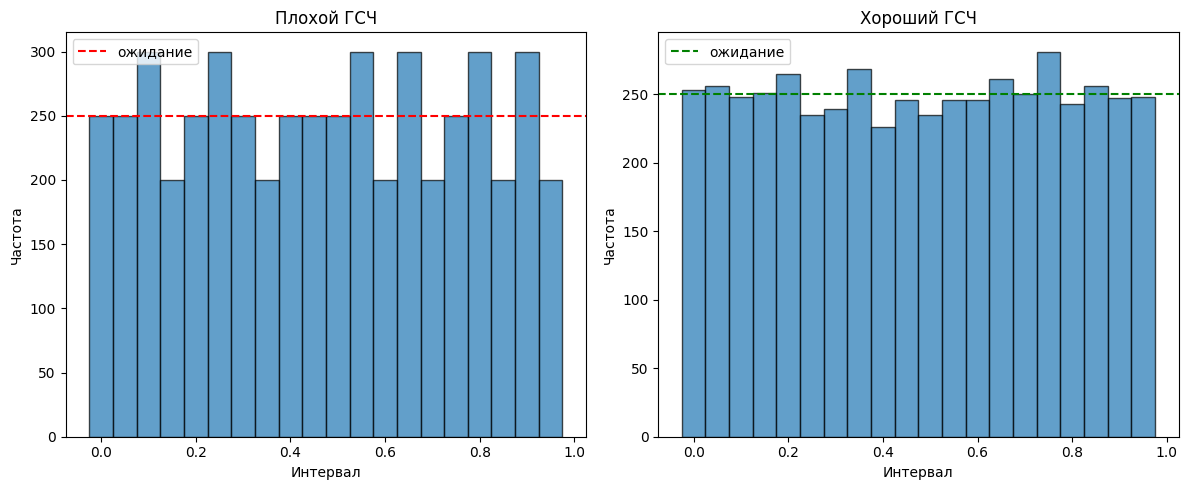

In [22]:
#задача 3
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare

class RngBad:
    def __init__(self, seed=1):
        self.state = seed
        self.a = 21
        self.c = 1
        self.m = 100
        self.max_val = self.m - 1

    def random(self):
        self.state = (self.a * self.state + self.c) % self.m
        return self.state / self.m

class RngGood:
    def __init__(self, seed=None):
        if seed is not None:
            random.seed(seed)
    def random(self):
        return random.random()

def chi_square_uniform(rng, num_samples=10000, num_bins=20):

    samples = [rng.random() for _ in range(num_samples)]
    observed, bin_edges = np.histogram(samples, bins=num_bins, range=(0, 1))
    expected = [num_samples / num_bins] * num_bins
    chi2, p_value = chisquare(observed, expected)
    return chi2, p_value, observed, bin_edges

def main():
    bad_rng = RngBad(seed=123)
    good_rng = RngGood(seed=123)

    n_samples = 5000
    n_bins = 20

    print("Тест хи-квадрат на равномерность")
    print("-" * 60)

    chi2_bad, p_bad, obs_bad, edges_bad = chi_square_uniform(bad_rng, n_samples, n_bins)
    print(f"Плохой ГСЧ: chi2 = {chi2_bad:.2f}, p-value = {p_bad:.3e}")
    if p_bad < 0.01:
        print("  → p-value очень мал, распределение значимо отличается от равномерного (проблемы!)")
    else:
        print("  → p-value > 0.01, распределение не противоречит равномерному")

    chi2_good, p_good, obs_good, edges_good = chi_square_uniform(good_rng, n_samples, n_bins)
    print(f"\nХороший ГСЧ: chi2 = {chi2_good:.2f}, p-value = {p_good:.3f}")
    if p_good < 0.01:
        print("  → p-value < 0.01, возможно, проблемы? (стоит проверить с другими параметрами)")
    else:
        print("  → p-value > 0.01, распределение равномерное (OK)")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].bar(edges_bad[:-1], obs_bad, width=edges_bad[1]-edges_bad[0], alpha=0.7, edgecolor='black')
    axes[0].axhline(y=n_samples/n_bins, color='red', linestyle='--', label='ожидание')
    axes[0].set_title('Плохой ГСЧ')
    axes[0].set_xlabel('Интервал')
    axes[0].set_ylabel('Частота')
    axes[0].legend()

    axes[1].bar(edges_good[:-1], obs_good, width=edges_good[1]-edges_good[0], alpha=0.7, edgecolor='black')
    axes[1].axhline(y=n_samples/n_bins, color='green', linestyle='--', label='ожидание')
    axes[1].set_title('Хороший ГСЧ')
    axes[1].set_xlabel('Интервал')
    axes[1].set_ylabel('Частота')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

Нормированные вероятности: [0.05973121 0.14932802 0.08312593 0.11946242 0.15430562 0.26879044
 0.05525137 0.0099552  0.00049776 0.09955202]


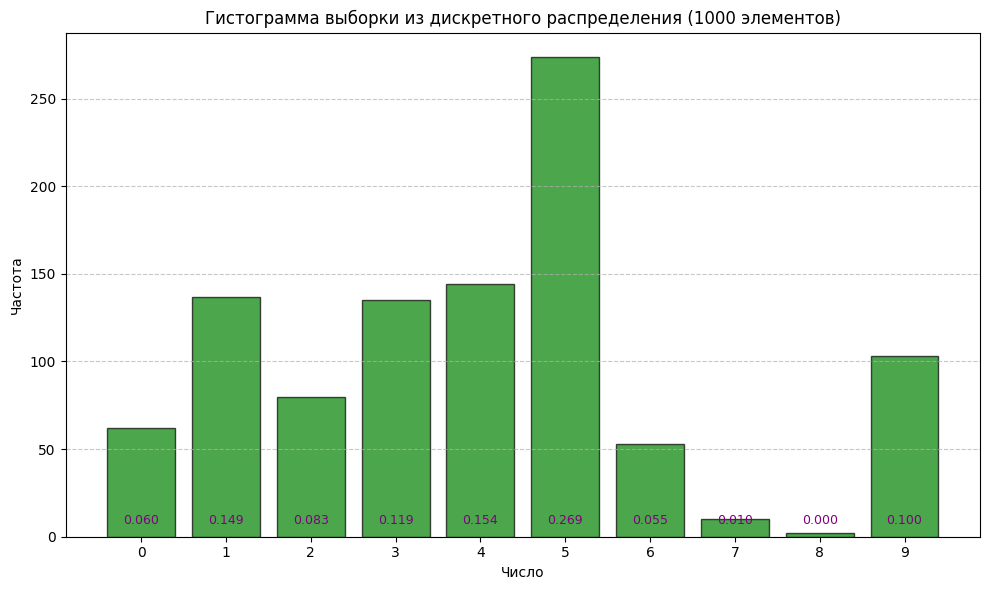

Ожидаемые частоты: [ 59.73120956 149.32802389  83.1259333  119.46241911 154.30562469
 268.79044301  55.25136884   9.95520159   0.49776008  99.55201593]
Наблюдаемые частоты: [ 62 137  80 135 144 274  53  10   2 103]


In [27]:
#задача 4
import numpy as np
import matplotlib.pyplot as plt

digits = np.arange(10)
weights = np.array([0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2])

probs = weights / weights.sum()
print("Нормированные вероятности:", probs)

sorted_indices = np.argsort(probs)[::-1]
sorted_digits = digits[sorted_indices]
sorted_probs = probs[sorted_indices]

cum_probs = np.cumsum(sorted_probs)

n_samples = 1000
samples = np.zeros(n_samples, dtype=int)

for i in range(n_samples):
    r = np.random.random()
    idx = 0
    while r > cum_probs[idx]:
        idx += 1
    samples[i] = sorted_digits[idx]

plt.figure(figsize=(10, 6))
plt.hist(samples, bins=10, range=(-0.5, 9.5), align='mid', rwidth=0.8, alpha=0.7, color='green', edgecolor='black')
plt.xticks(digits)
plt.xlabel('Число')
plt.ylabel('Частота')
plt.title('Гистограмма выборки из дискретного распределения (1000 элементов)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, prob in enumerate(probs):
    plt.text(i, max(np.bincount(samples, minlength=10)) * 0.02, f'{prob:.3f}',
             ha='center', va='bottom', fontsize=9, color='purple')

plt.tight_layout()
plt.show()

expected_freq = probs * n_samples
observed_freq = np.bincount(samples, minlength=10)
print("Ожидаемые частоты:", expected_freq)
print("Наблюдаемые частоты:", observed_freq)

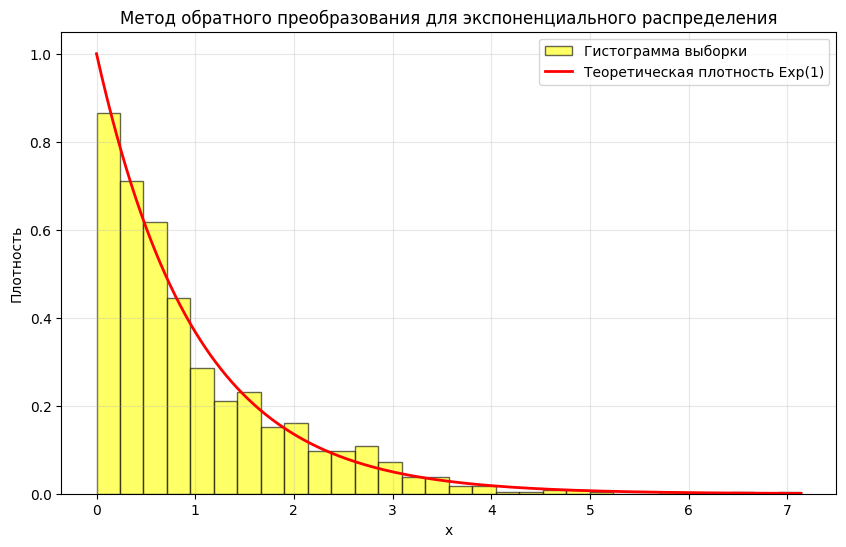

In [17]:
#задача 5
import numpy as np
import matplotlib.pyplot as plt

lambda_param = 1.0
n = 1000
u = np.random.uniform(0, 1, n)
x = -np.log(1 - u) / lambda_param

plt.figure(figsize=(10, 6))
plt.hist(x, bins=30, density=True, alpha=0.6, color='yellow', edgecolor='black', label='Гистограмма выборки')
x_vals = np.linspace(0, np.max(x), 1000)
density = lambda_param * np.exp(-lambda_param * x_vals)
plt.plot(x_vals, density, 'r-', linewidth=2, label='Теоретическая плотность Exp(1)')
plt.xlabel('x')
plt.ylabel('Плотность')
plt.title('Метод обратного преобразования для экспоненциального распределения')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

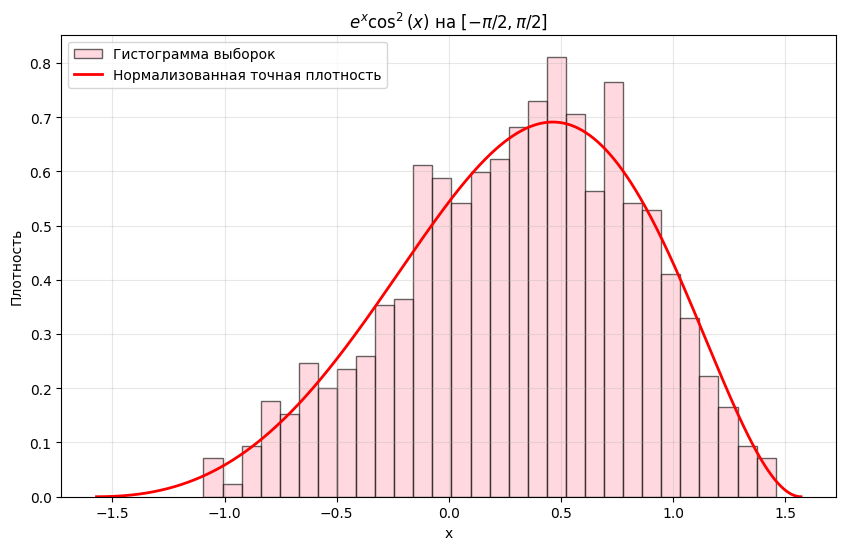

In [26]:
#задача 6
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import minimize_scalar

def f(x):
    return np.exp(x) * np.cos(x) ** 2

a, b = -np.pi / 2, np.pi / 2
x_plot = np.linspace(a, b, 1000)
f_plot = f(x_plot)

res = minimize_scalar(lambda x: -f(x), bounds=(a, b), method='bounded')
max_f = -res.fun
c = max_f * (b - a)

n_samples = 1000
samples = []
while len(samples) < n_samples:
    x = np.random.uniform(a, b)
    u = np.random.uniform(0, 1)
    if u < f(x) / (c * 1/(b-a)):
        samples.append(x)

samples = np.array(samples)

norm, _ = quad(f, a, b)

plt.figure(figsize=(10, 6))
plt.hist(samples, bins=30, density=True, alpha=0.6, color='pink', edgecolor='black', label='Гистограмма выборок')
plt.plot(x_plot, f(x_plot) / norm, 'r-', linewidth=2, label='Нормализованная точная плотность')
plt.xlabel('x')
plt.ylabel('Плотность')
plt.title(r'$e^x \cos^2(x)$ на $[-\pi/2, \pi/2]$')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

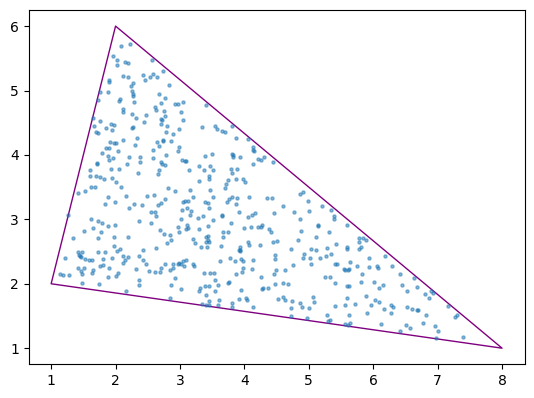

In [30]:
#задача 7
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

vertices = np.array([[1, 2], [2, 6], [8, 1]])
n = 500
points = []
for _ in range(n):
    u, v = np.random.rand(2)
    if u + v > 1:
        u, v = 1 - u, 1 - v
    point = (1 - u - v) * vertices[0] + u * vertices[1] + v * vertices[2]
    points.append(point)
points = np.array(points)

fig, ax = plt.subplots()
polygon = Polygon(vertices, closed=True)
ax.add_collection(PatchCollection([polygon], facecolor='none', edgecolor='purple'))
ax.scatter(points[:, 0], points[:, 1], s=5, alpha=0.5)
ax.set_aspect('equal')
plt.show()

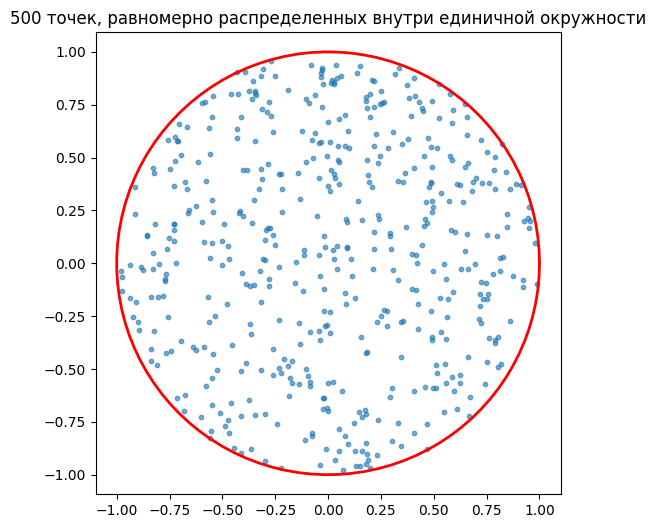

In [34]:
#задача 8
import numpy as np
import matplotlib.pyplot as plt

n = 500
theta = 2 * np.pi * np.random.rand(n)
r = np.sqrt(np.random.rand(n))
x = r * np.cos(theta)
y = r * np.sin(theta)

plt.figure(figsize=(6,6))
t = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(t), np.sin(t), 'r-', linewidth=2)
plt.scatter(x, y, s=10, alpha=0.6)
plt.axis('equal')
plt.title('500 точек, равномерно распределенных внутри единичной окружности')
plt.show()

Точное среднее: [4 7]
Выборочное среднее: [3.78495009 7.01385289]
Точная ковариационная матрица:
 [[20 -4]
 [-4 40]]
Выборочная ковариационная матрица:
 [[20.12098836 -2.20506399]
 [-2.20506399 40.17792451]]


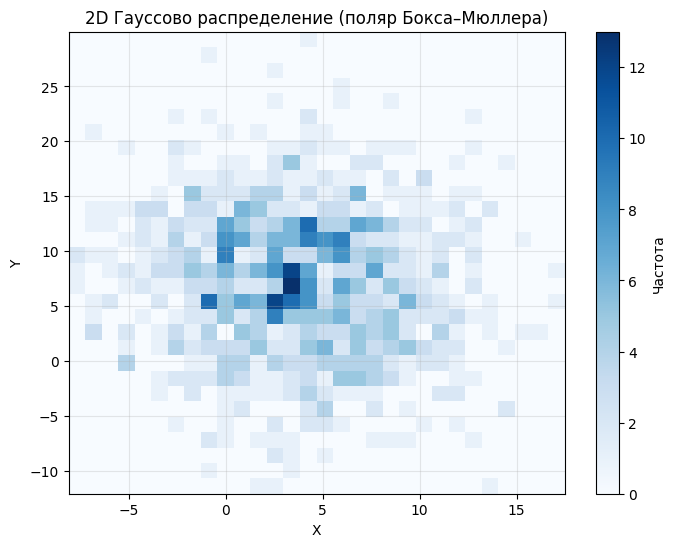

In [33]:
#задача 9
import numpy as np
import matplotlib.pyplot as plt

def box_muller_polar(n):
    z = np.zeros((n, 2))
    i = 0
    while i < n:
        u1 = 2 * np.random.rand() - 1
        u2 = 2 * np.random.rand() - 1
        s = u1 * u1 + u2 * u2
        if s < 1 and s > 0:
            factor = np.sqrt(-2 * np.log(s) / s)
            z[i] = [u1 * factor, u2 * factor]
            i += 1
    return z

n_samples = 1000
z = box_muller_polar(n_samples)

mu = np.array([4, 7])
Sigma = np.array([[20, -4], [-4, 40]])
L = np.linalg.cholesky(Sigma)
x = mu + z @ L.T

sample_mean = np.mean(x, axis=0)
sample_cov = np.cov(x, rowvar=False)

print("Точное среднее:", mu)
print("Выборочное среднее:", sample_mean)
print("Точная ковариационная матрица:\n", Sigma)
print("Выборочная ковариационная матрица:\n", sample_cov)

plt.figure(figsize=(8, 6))
plt.hist2d(x[:, 0], x[:, 1], bins=30, cmap='Blues')
plt.colorbar(label='Частота')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('2D Гауссово распределение (поляр Бокса–Мюллера)')
plt.grid(alpha=0.3)
plt.show()